In [77]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-haiku-4-5"

In [78]:
# Helper functions
from anthropic.types import Message

def add_user_message(messages, message):
    user_message = {
        "role": "user",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(assistant_message)



def chat(messages, system=None, temperature=1.0, stop_sequences=[], tools=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message


def text_from_message(message):
    """"Returns the only the text inside the text blocks
    """
    return "\n".join([block.text for block in message.content if block.type == "text"])

In [ ]:
# Tools and Schemas

from datetime import datetime, timedelta


def add_duration_to_datetime(
    datetime_str, duration=0, unit="days", input_format="%Y-%m-%d"
):
    date = datetime.strptime(datetime_str, input_format)

    if unit == "seconds":
        new_date = date + timedelta(seconds=duration)
    elif unit == "minutes":
        new_date = date + timedelta(minutes=duration)
    elif unit == "hours":
        new_date = date + timedelta(hours=duration)
    elif unit == "days":
        new_date = date + timedelta(days=duration)
    elif unit == "weeks":
        new_date = date + timedelta(weeks=duration)
    elif unit == "months":
        month = date.month + duration
        year = date.year + month // 12
        month = month % 12
        if month == 0:
            month = 12
            year -= 1
        day = min(
            date.day,
            [
                31,
                29 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 28,
                31,
                30,
                31,
                30,
                31,
                31,
                30,
                31,
                30,
                31,
            ][month - 1],
        )
        new_date = date.replace(year=year, month=month, day=day)
    elif unit == "years":
        new_date = date.replace(year=date.year + duration)
    else:
        raise ValueError(f"Unsupported time unit: {unit}")

    return new_date.strftime("%A, %B %d, %Y %I:%M:%S %p")


def set_reminder(content, timestamp):
    print(f"----\nSetting the following reminder for {timestamp}:\n{content}\n----")


add_duration_to_datetime_schema = {
    "name": "add_duration_to_datetime",
    "description": "Adds a specified duration to a datetime string and returns the resulting datetime in a detailed format. This tool converts an input datetime string to a Python datetime object, adds the specified duration in the requested unit, and returns a formatted string of the resulting datetime. It handles various time units including seconds, minutes, hours, days, weeks, months, and years, with special handling for month and year calculations to account for varying month lengths and leap years. The output is always returned in a detailed format that includes the day of the week, month name, day, year, and time with AM/PM indicator (e.g., 'Thursday, April 03, 2025 10:30:00 AM').",
    "input_schema": {
        "type": "object",
        "properties": {
            "datetime_str": {
                "type": "string",
                "description": "The input datetime string to which the duration will be added. This should be formatted according to the input_format parameter.",
            },
            "duration": {
                "type": "number",
                "description": "The amount of time to add to the datetime. Can be positive (for future dates) or negative (for past dates). Defaults to 0.",
            },
            "unit": {
                "type": "string",
                "description": "The unit of time for the duration. Must be one of: 'seconds', 'minutes', 'hours', 'days', 'weeks', 'months', or 'years'. Defaults to 'days'.",
            },
            "input_format": {
                "type": "string",
                "description": "The format string for parsing the input datetime_str, using Python's strptime format codes. For example, '%Y-%m-%d' for ISO format dates like '2025-04-03'. Defaults to '%Y-%m-%d'.",
            },
        },
        "required": ["datetime_str"],
    },
}

set_reminder_schema = {
    "name": "set_reminder",
    "description": "Creates a timed reminder that will notify the user at the specified time with the provided content. This tool schedules a notification to be delivered to the user at the exact timestamp provided. It should be used when a user wants to be reminded about something specific at a future point in time. The reminder system will store the content and timestamp, then trigger a notification through the user's preferred notification channels (mobile alerts, email, etc.) when the specified time arrives. Reminders are persisted even if the application is closed or the device is restarted. Users can rely on this function for important time-sensitive notifications such as meetings, tasks, medication schedules, or any other time-bound activities.",
    "input_schema": {
        "type": "object",
        "properties": {
            "content": {
                "type": "string",
                "description": "The message text that will be displayed in the reminder notification. This should contain the specific information the user wants to be reminded about, such as 'Take medication', 'Join video call with team', or 'Pay utility bills'.",
            },
            "timestamp": {
                "type": "string",
                "description": "The exact date and time when the reminder should be triggered, formatted as an ISO 8601 timestamp (YYYY-MM-DDTHH:MM:SS) or a Unix timestamp. The system handles all timezone processing internally, ensuring reminders are triggered at the correct time regardless of where the user is located. Users can simply specify the desired time without worrying about timezone configurations.",
            },
        },
        "required": ["content", "timestamp"],
    },
}

batch_tool_schema = {
    "name": "batch_tool",
    "description": "Invoke multiple other tool calls simultaneously",
    "input_schema": {
        "type": "object",
        "properties": {
            "invocations": {
                "type": "array",
                "description": "The tool calls to invoke",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string",
                            "description": "The name of the tool to invoke",
                        },
                        "arguments": {
                            "type": "string",
                            "description": "The arguments to the tool, encoded as a JSON string",
                        },
                    },
                    "required": ["name", "arguments"],
                },
            }
        },
        "required": ["invocations"],
    },
}

pass

# Simple Tool Function

In [22]:
#get_current_datetime
def get_current_datetime(date_format="%Y-%m-%d %H:%M:%S"):
    """Returns the current date and time as a formatted string.

    Args:
        date_format: A non-empty Python strftime format string. Defaults to
            '%Y-%m-%d %H:%M:%S' (e.g., '2025-04-03 10:30:00').
    """
    if not isinstance(date_format, str) or not date_format.strip():
        raise ValueError("date_format must be a non-empty string")
    return datetime.now().strftime(date_format)

from anthropic.types import ToolParam

get_current_datetime_schema = ToolParam({
    "name": "get_current_datetime",
    "description": "Returns the current date and time as a formatted string. Use this tool whenever you need to know the current moment in time, for example to compute relative dates, timestamp an action, or anchor reasoning that depends on 'now'. The output is formatted using a Python strftime format string supplied by the caller, defaulting to the common 'YYYY-MM-DD HH:MM:SS' format (e.g., '2025-04-03 10:30:00').",
    "input_schema": {
        "type": "object",
        "properties": {
            "date_format": {
                "type": "string",
                "description": "A Python strftime format string used to format the current datetime. Must be a non-empty string. For example, '%Y-%m-%d %H:%M:%S' for '2025-04-03 10:30:00', or '%Y-%m-%d' for date-only output. Defaults to '%Y-%m-%d %H:%M:%S'.",
                "minLength": 1,
            }
        },
        "required": [],
    },
})

# Assitant without Tool usage

In [58]:
messages = []
messages.append(
    {
        "role": "user",
        "content": "What is the exact time formatted in HH MM SS"
    }
)

response = client.messages.create(
    model = model,
    max_tokens=1000,
    messages = messages
)
text_block = response.content[0]
print(text_block.text)

I don't have access to real-time information, so I can't tell you the current time. 

To find the exact time in HH:MM:SS format, you can:
- Check your device's clock
- Search "current time" online
- Ask your voice assistant (Siri, Google Assistant, Alexa, etc.)

If you let me know your timezone, I can help you understand what time it might be!


# Assistant with Tool Usage

In [60]:
#Start context all over
messages = [] 
messages.append(
    {
        "role": "user",
        "content": "What is the exact time formatted in HH MM SS"
    }
)
response = client.messages.create(
    model = model,
    max_tokens=1000,
    messages = messages,
    tools=[get_current_datetime_schema]
)

print(response)

Message(id='msg_01K6Vce54RXKBDoCEfeSDzME', container=None, content=[ToolUseBlock(id='toolu_01Nb5rPRCsuXBmZaSxz4CgBf', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')], model='claude-haiku-4-5-20251001', role='assistant', stop_details=None, stop_reason='tool_use', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=760, output_tokens=63, server_tool_use=None, service_tier='standard'))


## Add Tool Usage Request

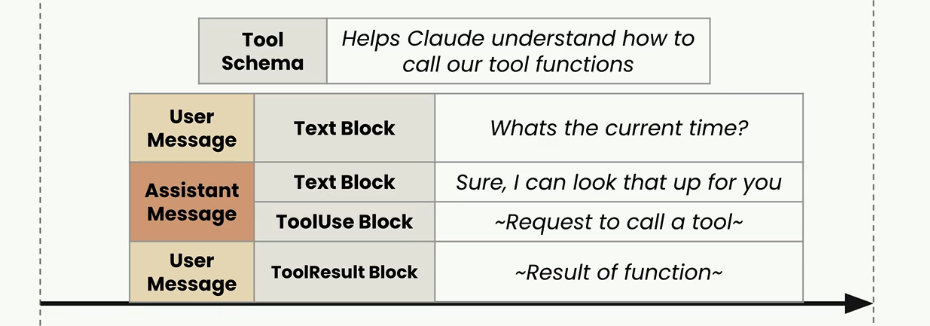

Add the tool usage request to the agent's context


In [69]:
messages.append(
    {
        "role": "assistant",
        "content": response.content
    }
)
messages

[{'role': 'user', 'content': 'What is the exact time formatted in HH MM SS'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_01Nb5rPRCsuXBmZaSxz4CgBf', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01Nb5rPRCsuXBmZaSxz4CgBf',
    'content': '16:25:49',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text='The exact time formatted in HH:MM:SS is **16:25:49** (4:25:49 PM).', type='text')]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text='The exact time formatted in HH:MM:SS is **16:25:49** (4:25:49 PM).', type='text')]}]

## Parse Tool Block Id and Input
The assistant responds with tool invocation

In [62]:
# in the video the tool use block is in the second index (1) for my execution, it only contain Tool Use block
# Message(id='msg_01AkrYtoRZWRcwpv4TdRcqEK', 
# container=None, 
# content=[ToolUseBlock(
#       id='toolu_013WmgmwLQCvp13AGtfekNzy', 
#       caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, 
#       name='get_current_datetime', type='tool_use')
# ] 
# , model='claude-haiku-4-5-20251001', 
# role='assistant', stop_details=None, stop_reason='tool_use', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=760, output_tokens=63, server_tool_use=None, service_tier='standard'))


tool_use_block = response.content[0]
print(tool_use_block.id)
print(tool_use_block.input)

toolu_01Nb5rPRCsuXBmZaSxz4CgBf
{'date_format': '%H:%M:%S'}


## Invoke Tool 

In [63]:
tool_result = get_current_datetime( **tool_use_block.input)
tool_result

'16:25:49'

## Add Result to messages

In [64]:
messages.append(
    {
        "role": "user",
        "content": [
            {
                "type": "tool_result",
                "tool_use_id": tool_use_block.id,
                "content": tool_result,
                "is_error": False
            }
        ]
    }
)
messages

[{'role': 'user', 'content': 'What is the exact time formatted in HH MM SS'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_01Nb5rPRCsuXBmZaSxz4CgBf', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01Nb5rPRCsuXBmZaSxz4CgBf',
    'content': '16:25:49',
    'is_error': False}]}]

## Get response from assistant, post tool call

In [65]:
response = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema]
)
response

Message(id='msg_01XrGsfQv3kBCtymtjafXDnd', container=None, content=[TextBlock(citations=None, text='The exact time formatted in HH:MM:SS is **16:25:49** (4:25:49 PM).', type='text')], model='claude-haiku-4-5-20251001', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=840, output_tokens=31, server_tool_use=None, service_tier='standard'))

In [67]:
print(response.content[0])

TextBlock(citations=None, text='The exact time formatted in HH:MM:SS is **16:25:49** (4:25:49 PM).', type='text')


## Understanding Tool Use

# Run Conversation


## Mapping from Tool Request to Response

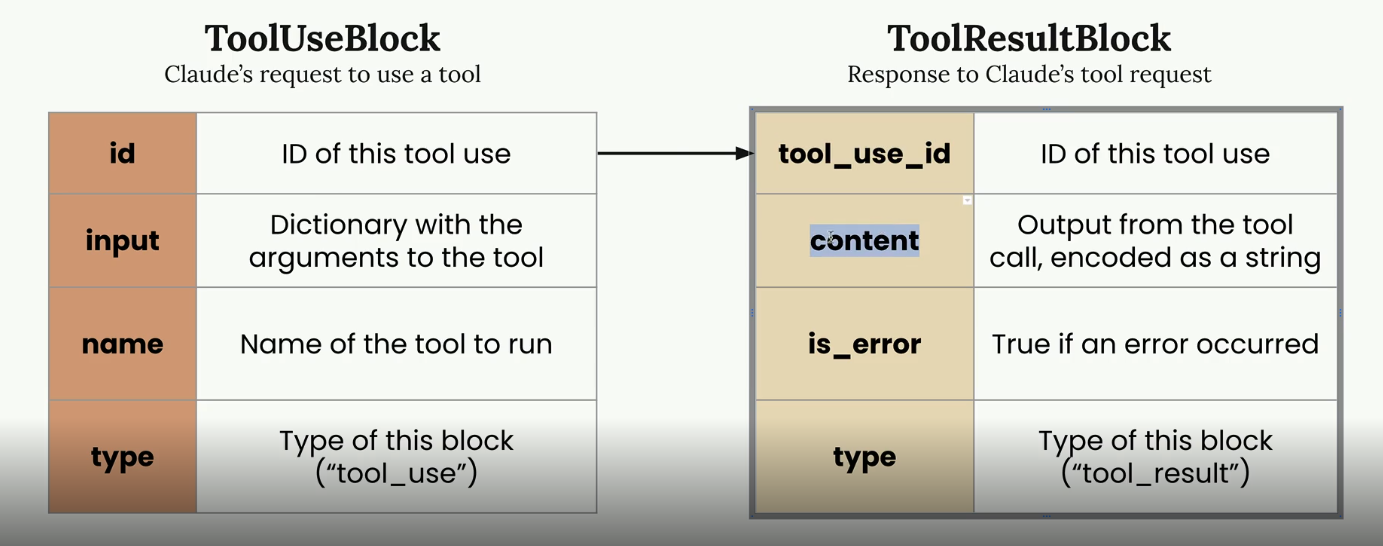

In [83]:
import json

def run_tool(tool_name, tool_input):
    if tool_name == "get_current_datetime":
        return get_current_datetime(**tool_input)
    elif tool_name == "add_duration_to_datetime":
        return add_duration_to_datetime(**tool_input)
    elif tool_name == "set_reminder":
        return set_reminder(**tool_input)
    


def run_tools(message):
    tool_requests = [block for block in message.content if block.type == "tool_use"]
    tool_result_blocks = []

    for tool_request in tool_requests:
        try:
            tool_output = run_tool(tool_request.name, tool_request.input)
            tool_result_block = {
                "type": "tool_result",
                "tool_use_id": tool_request.id,
                "content": json.dumps(tool_output),
                "is_error": False,
            }
        except Exception as e:
            tool_result_block = {
                "type": "tool_result",
                "tool_use_id": tool_request.id,
                "content": f"Error: {e}",
                "is_error": True,
            }

        tool_result_blocks.append(tool_result_block)

    return tool_result_blocks

In [85]:
def run_conversation(messages):
    while True:
        response = chat(
            messages,
            tools = [get_current_datetime_schema, add_duration_to_datetime_schema, set_reminder_schema] )
        add_assistant_message(messages, response)
        #print(text_from_message(response))
        print(response)

        if response.stop_reason != "tool_use":
            break

        tool_results = run_tools(response)
        add_user_message(messages, tool_results)
        
    return messages

In [87]:
messages = []
add_user_message(
    messages,
    "Set a reminder for my doctors appointment. Its 177 days after Jan 1st, 2050. Also, how many weeks will that appointment be from today",
)
run_conversation(messages)

Message(id='msg_01GHhU6y31VvFvExEA4mSWB7', container=None, content=[TextBlock(citations=None, text="I'll help you with that! Let me first figure out what date that appointment is, and then calculate how many weeks from today.", type='text'), ToolUseBlock(id='toolu_01FP5LYoizumeEHPpzcBBS4x', caller=DirectCaller(type='direct'), input={'datetime_str': '2050-01-01', 'duration': 177, 'unit': 'days'}, name='add_duration_to_datetime', type='tool_use'), ToolUseBlock(id='toolu_01EofjGBvnGXE5Hug9AGFtHe', caller=DirectCaller(type='direct'), input={'date_format': '%Y-%m-%d'}, name='get_current_datetime', type='tool_use')], model='claude-haiku-4-5-20251001', role='assistant', stop_details=None, stop_reason='tool_use', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=1532, output_tokens=171, server_tool_use=None, 

[{'role': 'user',
  'content': 'Set a reminder for my doctors appointment. Its 177 days after Jan 1st, 2050. Also, how many weeks will that appointment be from today'},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="I'll help you with that! Let me first figure out what date that appointment is, and then calculate how many weeks from today.", type='text'),
   ToolUseBlock(id='toolu_01FP5LYoizumeEHPpzcBBS4x', caller=DirectCaller(type='direct'), input={'datetime_str': '2050-01-01', 'duration': 177, 'unit': 'days'}, name='add_duration_to_datetime', type='tool_use'),
   ToolUseBlock(id='toolu_01EofjGBvnGXE5Hug9AGFtHe', caller=DirectCaller(type='direct'), input={'date_format': '%Y-%m-%d'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01FP5LYoizumeEHPpzcBBS4x',
    'content': '"Monday, June 27, 2050 12:00:00 AM"',
    'is_error': False},
   {'type': 'tool_result',
    'tool_use_id': 'to

## Multi-Turn Conversation Trace

---

### 🧑 Turn 1 — User
> Set a reminder for my doctors appointment. Its 177 days after Jan 1st, 2050. Also, how many weeks will that appointment be from today

---

### 🤖 Turn 2 — Assistant

I'll help you with that! Let me first figure out what date that appointment is, and then calculate how many weeks from today.

**🔧 Tool Calls (parallel)**

| # | Tool | Input |
|---|------|-------|
| A | `add_duration_to_datetime` | `datetime_str: "2050-01-01"`, `duration: 177`, `unit: "days"` |
| B | `get_current_datetime` | `date_format: "%Y-%m-%d"` |

---

### 🛠️ Turn 3 — Tool Results

| # | Tool Use ID | Result |
|---|-------------|--------|
| A | `toolu_01FP5...` → `add_duration_to_datetime` | ✅ `"Monday, June 27, 2050 12:00:00 AM"` |
| B | `toolu_01Eof...` → `get_current_datetime` | ✅ `"2026-05-08"` |

---

### 🤖 Turn 4 — Assistant

Great! Your doctor's appointment is on **Monday, June 27, 2050**. Now let me calculate how many weeks that is from today and set your reminder.

**🔧 Tool Calls (parallel)**

| # | Tool | Input |
|---|------|-------|
| C | `add_duration_to_datetime` | `datetime_str: "2026-05-08"`, `duration: 24`, `unit: "years"`, `input_format: "%Y-%m-%d"` |
| D | `set_reminder` | `content: "Doctor's appointment"`, `timestamp: "2050-06-27T09:00:00"` |

---

### 🛠️ Turn 5 — Tool Results

| # | Tool Use ID | Result |
|---|-------------|--------|
| C | `toolu_012n...` → `add_duration_to_datetime` | ✅ `"Sunday, May 08, 2050 12:00:00 AM"` |
| D | `toolu_01YY...` → `set_reminder` | ✅ `null` (reminder set successfully) |

---

### 🤖 Turn 6 — Final Response

✅ **Reminder Set**: Doctor's appointment reminder set for **Monday, June 27, 2050 at 9:00 AM**

📅 **Time Until Appointment**: ~**24 years and 50 days** from today (May 8, 2026) — roughly **1,250 weeks**

---

> **Note — Tool C reasoning gap**: The assistant called `add_duration_to_datetime` with `+24 years` from today to estimate the delta, but used the result loosely. The actual diff between `2026-05-08` and `2050-06-27` is **24 years, 50 days ≈ 1,257 weeks**. The reminder itself was correctly set to `2050-06-27`.